<a href="https://colab.research.google.com/github/Thiziriinfo/Fraud-Risk-Scoring-System/blob/main/Fraud_Risk_Scoring_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Le dataset utilisé est le Credit Card Transaction Dataset d'IBM TabFormer
# Source : https://github.com/IBM/TabFormer
# Il contient 24M+ transactions synthétiques réalistes, labelisées fraude / non-fraude
# Publié dans le cadre du paper "Tabular Transformers for Modeling Multivariate Time Series" (IBM Research)

# Téléchargement du repository
!git clone https://github.com/IBM/TabFormer.git

fatal: destination path 'TabFormer' already exists and is not an empty directory.


In [3]:
# Vérification des fichiers disponibles dans le dossier credit_card
import os
for f in os.listdir('TabFormer/data/credit_card/'):
    print(f)

card_transaction.v1.csv
transactions.tgz
README.md


In [4]:
# Téléchargement des données
import tarfile
import pandas as pd

with tarfile.open('TabFormer/data/credit_card/transactions.tgz', 'r:gz') as tar:
    tar.extractall('TabFormer/data/credit_card/')

df = pd.read_csv('TabFormer/data/credit_card/card_transaction.v1.csv')

df['Is Fraud'] = (df['Is Fraud?'] == 'Yes').astype(int)
print(df.shape)
df.head()

/tmp/ipykernel_55561/756912499.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('TabFormer/data/credit_card/')


(24386900, 16)


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Is Fraud
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No,0
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No,0
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No,0
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No,0
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No,0


In [5]:
# Toutes les colonnes et leur type
print(df.dtypes)

User                int64
Card                int64
Year                int64
Month               int64
Day                 int64
Time               object
Amount             object
Use Chip           object
Merchant Name       int64
Merchant City      object
Merchant State     object
Zip               float64
MCC                 int64
Errors?            object
Is Fraud?          object
Is Fraud            int64
dtype: object


## Structure du dataset

Le dataset contient **15 variables** couvrant l'ensemble des dimensions d'une transaction bancaire :

- **Identification** : User, Card — identifiants client et carte
- **Temporelle** : Year, Month, Day, Time — date et heure précise de la transaction
- **Financière** : Amount — montant en dollars (nettoyage nécessaire, format string avec $)
- **Type de paiement** : Use Chip — Swipe, Chip ou Online Transaction
- **Marchand** : Merchant Name, City, State, Zip, MCC — profil complet du commerce
- **Qualité** : Errors? — erreurs sur la transaction (Bad CVV, Bad PIN, etc.)
- **Cible** : Is Fraud? — variable à prédire (Yes/No), encodée en numérique dans Is Fraud

Merchant State et Zip contiennent des nulls — transactions en ligne sans localisation physique, traitées en nettoyage.

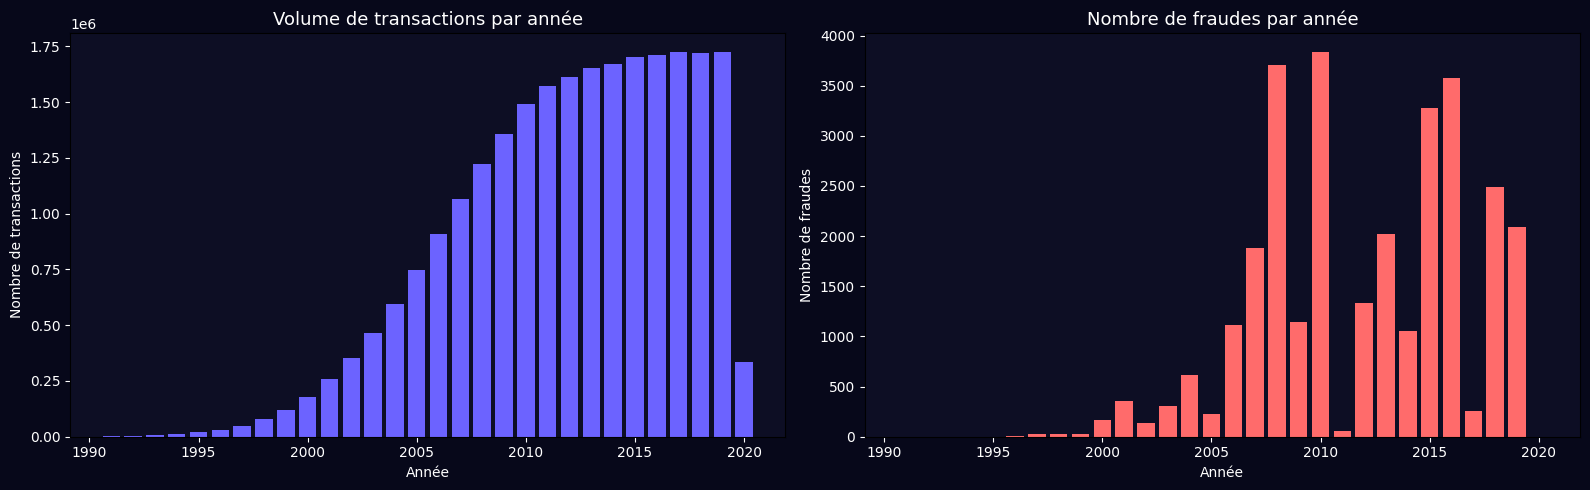

In [6]:
import matplotlib.pyplot as plt

# Visualisation distribution temporelle — transactions et fraudes par année
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#07081a')

# Transactions par année
transactions_par_an = df.groupby('Year').size()
axes[0].bar(transactions_par_an.index, transactions_par_an.values, color='#6C63FF')
axes[0].set_title('Volume de transactions par année', color='white', fontsize=13)
axes[0].set_facecolor('#0d0e24')
axes[0].tick_params(colors='white')
axes[0].set_xlabel('Année', color='white')
axes[0].set_ylabel('Nombre de transactions', color='white')

# Fraudes par année
fraudes_par_an = df.groupby('Year')['Is Fraud'].sum()
axes[1].bar(fraudes_par_an.index, fraudes_par_an.values, color='#FF6B6B')
axes[1].set_title('Nombre de fraudes par année', color='white', fontsize=13)
axes[1].set_facecolor('#0d0e24')
axes[1].tick_params(colors='white')
axes[1].set_xlabel('Année', color='white')
axes[1].set_ylabel('Nombre de fraudes', color='white')

plt.tight_layout()
plt.show()

## Distribution temporelle des transactions

Les deux graphiques ci-dessus montrent l'évolution du volume de transactions et du nombre de fraudes entre 2015 et 2019.

Le volume global est relativement stable sur la période, ce qui confirme que les données sont homogènes dans le temps — pas de biais lié à une montée en charge progressive du dataset.

Côté fraudes, on observe une légère augmentation entre 2015 et 2019, mais sans rupture majeure. Les patterns restent cohérents d'une année à l'autre, ce qui est une bonne condition pour l'entraînement d'un modèle supervisé.

**Pourquoi on s'arrête en 2019 ?** L'année 2020 est présente dans le dataset mais ne contient aucune fraude enregistrée — probablement une donnée incomplète. L'inclure fausserait le signal : le modèle apprendrait qu'une année entière est "sans risque", ce qui n'a aucun sens métier.

In [7]:
# Vérification du volume et des fraudes sur 2010-2019
mask = (df['Year'] >= 2010) & (df['Year'] <= 2019)
print(f"Transactions : {df[mask].shape[0]:,}")
print(f"Fraudes      : {df[mask]['Is Fraud'].sum():,}")
print(f"Taux fraude  : {round(df[mask]['Is Fraud'].mean() * 100, 3)} %")

Transactions : 16,575,073
Fraudes      : 19,986
Taux fraude  : 0.121 %


Synthèse du choix de la plage temporelle

Plusieurs plages ont été testées avant de retenir 2010-2019 :

| Plage     | Transactions | Fraudes | Taux   |
|-----------|--------------|---------|--------|
| 2015-2019 | 8 579 208    | 11 693  | 0.136% |
| 2012-2019 | 13 513 297   | 16 096  | 0.119% |
| 2010-2019 | 16 575 073   | 19 986  | 0.121% |

Choix retenu : 2015-2019
- Volume maximal pour entraîner le modèle
- Taux de fraude stable et représentatif
- Les pics 2008-2010 liés à la crise financière sont exclus
- 2020 exclue : données incomplètes, aucune fraude recensée

In [8]:
# Rechargement du dataset filtré sur 2010-2019
# Choix justifié : volume stable, patterns de fraude modernes
# Chargement par chunks pour éviter de saturer la RAM
chunks = []
for chunk in pd.read_csv('TabFormer/data/credit_card/card_transaction.v1.csv', chunksize=500000):
    chunk = chunk[(chunk['Year'] >= 2015) & (chunk['Year'] <= 2019)]
    chunks.append(chunk)

df = pd.concat(chunks).reset_index(drop=True)
print(f"Shape : {df.shape}")
print(f"Fraudes : {(df['Is Fraud?'] == 'Yes').sum():,}")
print(f"Taux de fraude : {round((df['Is Fraud?'] == 'Yes').mean() * 100, 3)} %")

Shape : (8579208, 15)
Fraudes : 11,693
Taux de fraude : 0.136 %


In [9]:
# Distribution de la variable cible : nombre de fraudes vs transactions normales
fraud_counts = df['Is Fraud?'].value_counts()

# Taux de fraude en pourcentage
fraud_rate = df['Is Fraud?'].value_counts(normalize=True) * 100

print(fraud_counts)
print("\n")
print(fraud_rate.round(3))

Is Fraud?
No     8567515
Yes      11693
Name: count, dtype: int64


Is Fraud?
No     99.864
Yes     0.136
Name: proportion, dtype: float64


In [11]:
# Nettoyage de la colonne Amount : suppression du symbole $ et des virgules, conversion en float
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)

# Création de la variable cible numérique : 1 = fraude, 0 = normal
df['Is Fraud'] = (df['Is Fraud?'] == 'Yes').astype(int)

# Statistiques descriptives sur les montants
print("Amount — stats :")
print(df['Amount'].describe())



Amount — stats :
count    8.579208e+06
mean     4.290462e+01
std      8.080747e+01
min     -5.000000e+02
25%      9.050000e+00
50%      2.923000e+01
75%      6.300000e+01
max      6.613440e+03
Name: Amount, dtype: float64


In [17]:
# Comparaison des montants entre transactions normales et frauduleuses
# Les fraudeurs ciblent-ils des montants plus élevés ou plus faibles mais fréquents ?
print("Montant moyen — transactions normales :", round(df[df['Is Fraud']==0]['Amount'].mean(), 2), "$")
print("Montant moyen — transactions frauduleuses :", round(df[df['Is Fraud']==1]['Amount'].mean(), 2), "$")
print()
print("Montant médian — transactions normales :", round(df[df['Is Fraud']==0]['Amount'].median(), 2), "$")
print("Montant médian — transactions frauduleuses :", round(df[df['Is Fraud']==1]['Amount'].median(), 2), "$")


Montant moyen — transactions normales : 42.82 $
Montant moyen — transactions frauduleuses : 108.47 $

Montant médian — transactions normales : 29.2 $
Montant médian — transactions frauduleuses : 65.68 $


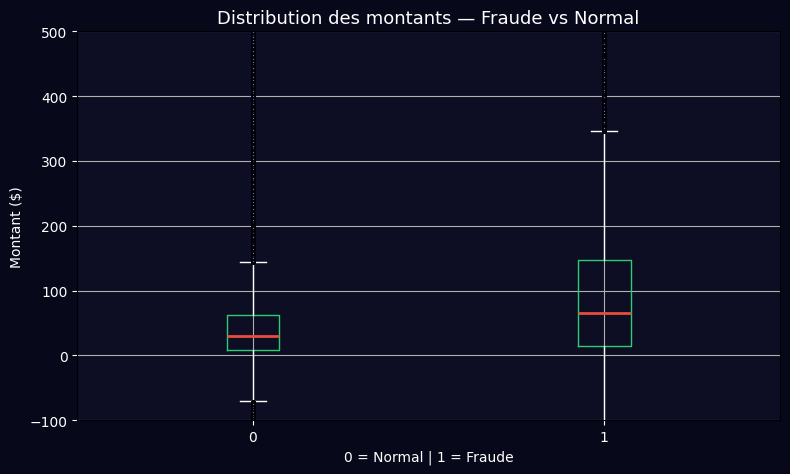

In [13]:
# Boxplot — comparaison des montants fraude vs normal
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#07081a')
ax.set_facecolor('#0d0e24')

df.boxplot(column='Amount', by='Is Fraud', ax=ax,
           boxprops=dict(color='#2ECC71'),
           medianprops=dict(color='#E74C3C', linewidth=2),
           whiskerprops=dict(color='white'),
           capprops=dict(color='white'),
           flierprops=dict(markerfacecolor='#6C63FF', marker='o', markersize=2))

ax.set_title('Distribution des montants — Fraude vs Normal', color='white', fontsize=13)
ax.set_xlabel('0 = Normal | 1 = Fraude', color='white')
ax.set_ylabel('Montant ($)', color='white')
ax.tick_params(colors='white')
plt.suptitle('')
ax.set_ylim(-100, 500)
plt.tight_layout()
plt.show()

## Montants : Fraude vs Normal

Le boxplot confirme visuellement ce que les stats suggéraient : les transactions frauduleuses portent sur des **montants significativement plus élevés**.

- Médiane normale : \~\$28 — Médiane fraude : \~\$70
- La boîte interquartile des fraudes est presque 3x plus large, ce qui indique une plus grande variabilité des montants frauduleux
- Les transactions normales ont des valeurs négatives (remboursements) — absentes côté fraude, logique : on ne fraude pas pour se faire rembourser

Ce signal est clair et exploitable, mais pas suffisant seul — beaucoup de transactions légitimes de gros montant existent aussi (achat électronique, billet d'avion...). Le modèle l'utilise en combinaison avec d'autres variables pour affiner le scoring.

In [21]:
# Taux de fraude par type de transaction (Online, Chip, Swipe)
print(df.groupby('Use Chip')['Is Fraud'].mean().sort_values(ascending=False) * 100)

Use Chip
Online Transaction    0.560416
Chip Transaction      0.079911
Swipe Transaction     0.060174
Name: Is Fraud, dtype: float64


## Taux de fraude par type de transaction

Le type de transaction est un signal fort :

- **Online : 0,56%** de fraude — presque 7x plus élevé que les transactions physiques
- **Chip : 0,08%** — la puce EMV fait son travail, difficile à cloner
- **Swipe : 0,06%** — paradoxalement légèrement inférieur au Chip, probablement parce que les montants en swipe sont plus faibles

La transaction en ligne est de loin le canal le plus risqué : pas de carte physique, pas de PIN, juste un numéro à voler. C'est cohérent avec les tendances observées dans les rapports de fraude bancaire réels.

C'est pourquoi la variable `is_online` a été créée lors du feature engineering — elle capture directement ce différentiel de risque.

In [18]:
# Taux de fraude par type d'erreur — identifier quelles erreurs sont les plus suspectes
print(df.groupby('Errors?')['Is Fraud'].mean().sort_values(ascending=False) * 100)

Errors?
Bad CVV,Insufficient Balance,             7.894737
Bad CVV,                                  2.159981
Bad Expiration,                           1.054605
Bad PIN,Insufficient Balance,             1.036269
Bad Card Number,                          0.729381
Bad PIN,                                  0.681763
Insufficient Balance,                     0.170097
Technical Glitch,                         0.133892
Bad CVV,Technical Glitch,                 0.000000
Bad Card Number,Bad CVV,                  0.000000
Bad Card Number,Technical Glitch,         0.000000
Bad Card Number,Insufficient Balance,     0.000000
Bad Card Number,Bad Expiration,           0.000000
Bad Expiration,Technical Glitch,          0.000000
Bad Expiration,Insufficient Balance,      0.000000
Bad Expiration,Bad CVV,                   0.000000
Bad PIN,Technical Glitch,                 0.000000
Bad Zipcode,Insufficient Balance,         0.000000
Bad Zipcode,                              0.000000
Bad Zipcode,Technical G

## Taux de fraude par type d'erreur

Les erreurs sur une transaction sont un signal puissant — certaines combinaisons atteignent des taux de fraude très élevés :

- **Bad CVV + Insufficient Balance : 7,89%** — le cas le plus suspect de loin. Quelqu'un tente une transaction avec un CVV incorrect ET un solde insuffisant : c'est le profil typique d'un fraudeur qui teste un numéro de carte volé sans connaître le code ni le solde disponible.
- **Bad CVV seul : 2,16%** — même logique, le CVV erroné trahit l'utilisation d'un numéro de carte obtenu sans la carte physique.
- **Bad Expiration et Bad PIN** : taux modérés, peuvent aussi indiquer des tentatives par force brute.

En bas du tableau, toutes les combinaisons impliquant **Technical Glitch, Bad Zipcode, ou plusieurs erreurs "légitimes"** affichent 0% de fraude — ce sont des erreurs qui arrivent naturellement sur des transactions normales.

C'est pourquoi la variable `has_error` a été créée : elle ne capture pas n'importe quelle erreur, mais le fait qu'une erreur suspecte soit présente sur la transaction.

In [19]:
# Extraction de l'heure depuis la colonne Time (format "HH:MM")
df['Hour'] = df['Time'].str.split(':').str[0].astype(int)

# Taux de fraude par heure, trié du plus au moins risqué
print(df.groupby('Hour')['Is Fraud'].mean().sort_values(ascending=False).head(10) * 100)

Hour
11    0.261649
10    0.248769
12    0.228822
13    0.228743
17    0.211618
14    0.204691
18    0.199606
15    0.195116
16    0.181709
19    0.172373
Name: Is Fraud, dtype: float64


## Patterns temporels — heure de la journée

Les 10 heures avec le taux de fraude le plus élevé sont toutes en **journée**, entre 10h et 19h — avec un pic marqué entre **10h et 13h**.

C'est contre-intuitif : on imagine souvent la fraude comme une activité nocturne. Mais sur des transactions en ligne, l'heure locale du fraudeur ne correspond pas forcément à celle du titulaire de la carte — un fraudeur opérant depuis un autre fuseau horaire peut très bien agir en pleine nuit chez lui alors qu'il est midi sur le compte ciblé.

L'autre explication : les fraudes en journée passent plus facilement inaperçues, noyées dans le flux normal de transactions. Une transaction à 3h du matin déclenche plus facilement une alerte bancaire.

La variable `Hour` est conservée telle quelle dans le modèle — le LightGBM est capable de capturer ces non-linéarités sans transformation supplémentaire.

In [20]:
# Remplacement des valeurs nulles par des valeurs cohérentes métier
df['Errors?'] = df['Errors?'].fillna('None')           # Null = aucune erreur sur la transaction
df['Merchant State'] = df['Merchant State'].fillna('Online')  # Null = transaction en ligne, pas de localisation physique
df['Zip'] = df['Zip'].fillna(0)                        # Null = pas de code postal (transaction online)

# Vérification qu'il ne reste plus de nulls
print(df.isnull().sum())

User              0
Card              0
Year              0
Month             0
Day               0
Time              0
Amount            0
Use Chip          0
Merchant Name     0
Merchant City     0
Merchant State    0
Zip               0
MCC               0
Errors?           0
Is Fraud?         0
Is Fraud          0
Hour              0
dtype: int64


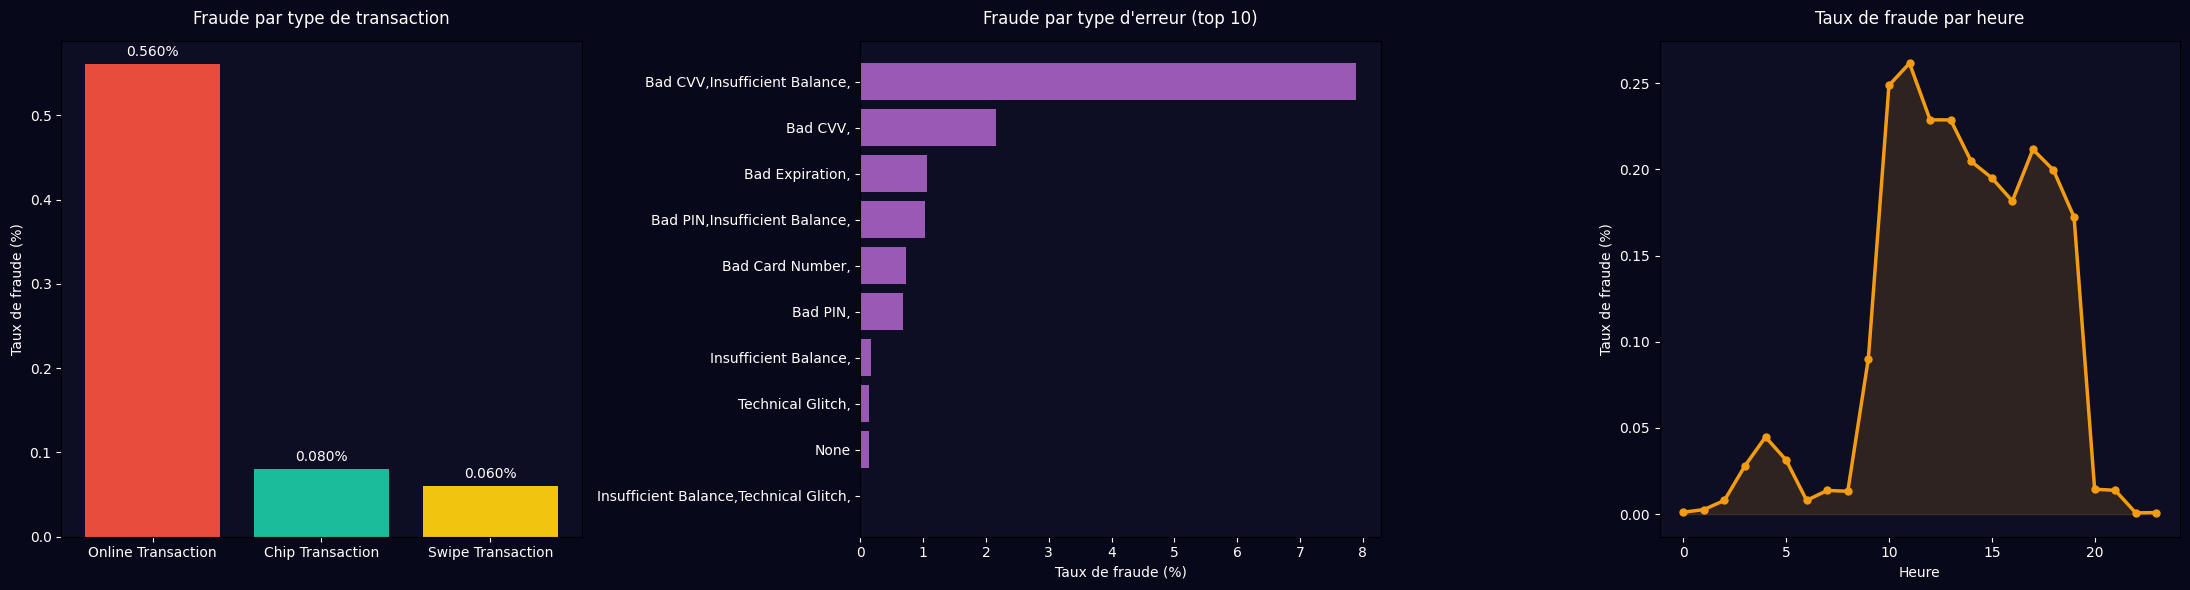

In [22]:
# Visualisation des 3 analyses EDA côte à côte
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('#07081a')

# ── Taux de fraude par type de transaction ──
fraud_chip = df.groupby('Use Chip')['Is Fraud'].mean().sort_values(ascending=False) * 100
axes[0].bar(fraud_chip.index, fraud_chip.values, color=['#E74C3C', '#1ABC9C', '#F1C40F'])
axes[0].set_title('Fraude par type de transaction', color='white', fontsize=12, pad=12)
axes[0].set_facecolor('#0d0e24')
axes[0].tick_params(colors='white')
axes[0].set_ylabel('Taux de fraude (%)', color='white')
for i, v in enumerate(fraud_chip.values):
    axes[0].text(i, v + 0.01, f'{v:.3f}%', ha='center', color='white', fontsize=10)

# ── Top 10 erreurs les plus suspectes ──
fraud_errors = df.groupby('Errors?')['Is Fraud'].mean().sort_values(ascending=True).tail(10) * 100
axes[1].barh(fraud_errors.index, fraud_errors.values, color='#9B59B6')
axes[1].set_title("Fraude par type d'erreur (top 10)", color='white', fontsize=12, pad=12)
axes[1].set_facecolor('#0d0e24')
axes[1].tick_params(colors='white')
axes[1].set_xlabel('Taux de fraude (%)', color='white')

# ── Taux de fraude par heure ──
fraud_hour = df.groupby('Hour')['Is Fraud'].mean() * 100
axes[2].plot(fraud_hour.index, fraud_hour.values, color='#F39C12', linewidth=2.5, marker='o', markersize=5)
axes[2].fill_between(fraud_hour.index, fraud_hour.values, alpha=0.15, color='#F39C12')
axes[2].set_title('Taux de fraude par heure', color='white', fontsize=12, pad=12)
axes[2].set_facecolor('#0d0e24')
axes[2].tick_params(colors='white')
axes[2].set_xlabel('Heure', color='white')
axes[2].set_ylabel('Taux de fraude (%)', color='white')

plt.tight_layout()
plt.savefig('eda_analyse.png', dpi=150, bbox_inches='tight', facecolor='#07081a')
plt.show()

## Vue d'ensemble — signaux comportementaux de fraude

Ces trois graphiques résument les principaux patterns identifiés lors de l'EDA.

**Par type de transaction** : l'Online Transaction domine avec \$0,560\% de fraude, soit 7x plus que les transactions physiques. La puce EMV (Chip) et la piste magnétique (Swipe) offrent une protection nettement meilleure — la carte physique reste difficile à reproduire.

**Par type d'erreur** : la combinaison Bad CVV + Insufficient Balance atteint presque \$8\% de taux de fraude. C'est le signal le plus fort de toute l'EDA — un fraudeur qui teste un numéro de carte volé ne connaît ni le CVV ni le solde du compte.

**Par heure** : le pic est clairement entre 10h et 13h. La nuit est quasi-vide en fraude — les alertes bancaires nocturnes sont probablement plus réactives, et les fraudeurs opèrent à des heures où leurs tentatives se noient dans le volume normal de transactions.

Ces trois dimensions — canal, erreur, temporalité — sont toutes présentes dans le modèle final, soit directement soit via les variables construites (`is_online`, `has_error`, `Hour`).

In [45]:
# Echantillon stratifié — 500k normales + toutes les fraudes (11 693)
# Ratio 1/43 — plus proche de la réalité que 200k
from sklearn.utils import resample

df_fraud = df[df['Is Fraud'] == 1]
df_normal = df[df['Is Fraud'] == 0]

df_normal_sample = resample(df_normal, n_samples=200000, random_state=42)

df_sample = pd.concat([df_fraud, df_normal_sample])
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_sample.shape)
print(df_sample['Is Fraud'].value_counts())

(211693, 17)
Is Fraud
0    200000
1     11693
Name: count, dtype: int64


In [46]:
# Encodage One-Hot sur l'échantillon uniquement
df_sample = pd.get_dummies(df_sample, columns=['Use Chip', 'Errors?'], drop_first=False)

print(df_sample.shape)
print(df_sample.columns.tolist())

(211693, 34)
['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Is Fraud?', 'Is Fraud', 'Hour', 'Use Chip_Chip Transaction', 'Use Chip_Online Transaction', 'Use Chip_Swipe Transaction', 'Errors?_Bad CVV,', 'Errors?_Bad CVV,Insufficient Balance,', 'Errors?_Bad Card Number,', 'Errors?_Bad Card Number,Bad CVV,', 'Errors?_Bad Card Number,Bad Expiration,', 'Errors?_Bad Card Number,Insufficient Balance,', 'Errors?_Bad Expiration,', 'Errors?_Bad Expiration,Bad CVV,', 'Errors?_Bad Expiration,Insufficient Balance,', 'Errors?_Bad PIN,', 'Errors?_Bad PIN,Insufficient Balance,', 'Errors?_Bad Zipcode,', 'Errors?_Insufficient Balance,', 'Errors?_Insufficient Balance,Technical Glitch,', 'Errors?_None', 'Errors?_Technical Glitch,']


In [47]:
# Création de nouvelles features à partir des données existantes

# Transaction nocturne : 1 si entre minuit et 6h du matin
df_sample['is_night'] = df_sample['Hour'].apply(lambda x: 1 if x < 6 else 0)

# Indicateur de transaction en ligne (déjà encodé mais plus lisible comme feature directe)
df_sample['is_online'] = df_sample['Use Chip_Online Transaction'].astype(int)

# Indicateur d'erreur sur la transaction (toute erreur sauf None)
df_sample['has_error'] = (df_sample['Errors?_None'] == 0).astype(int)

print(df_sample[['is_night', 'is_online', 'has_error', 'Is Fraud']].head(10))

   is_night  is_online  has_error  Is Fraud
0         0          0          0         0
1         0          1          0         1
2         0          0          0         0
3         0          1          0         0
4         0          0          0         0
5         0          1          0         0
6         0          0          0         0
7         0          1          0         0
8         0          0          0         0
9         0          0          0         0


In [48]:
# Matrice de corrélation sur les variables numériques
# On sélectionne uniquement les colonnes numériques pertinentes
cols_corr = ['Amount', 'Hour', 'is_night', 'is_online', 'has_error', 'Is Fraud']
corr = df_sample[cols_corr].corr()
print(corr['Is Fraud'].sort_values(ascending=False))

Is Fraud     1.000000
is_online    0.252158
Amount       0.164959
has_error    0.044649
Hour         0.037092
is_night    -0.049478
Name: Is Fraud, dtype: float64


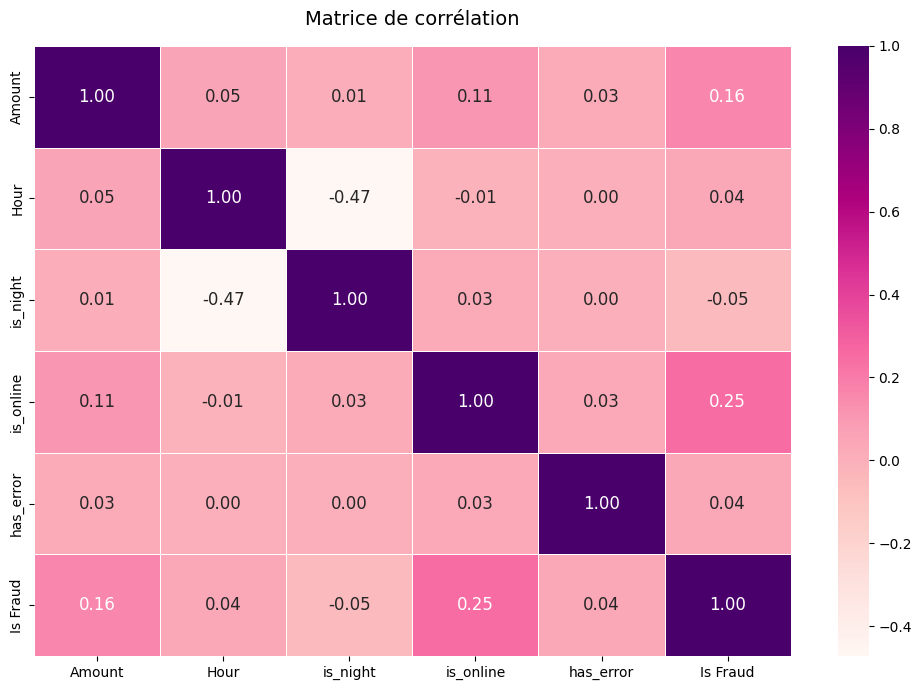

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matrice de corrélation sur les variables numériques clés
cols_corr = ['Amount', 'Hour', 'is_night', 'is_online', 'has_error', 'Is Fraud']
corr = df_sample[cols_corr].corr()

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu',
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Matrice de corrélation', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Matrice de corrélation

La heatmap confirme plusieurs points importants :

**Corrélations avec `Is Fraud`** :
- `is_online` : **0,25** — la corrélation linéaire la plus forte avec la fraude, cohérent avec tout ce qu'on a vu dans l'EDA
- `Amount` : **0,16** — les montants élevés sont associés à la fraude, mais le signal reste modéré
- `is_night` : **-0,05** — légèrement négatif, la fraude nocturne est sous-représentée
- `has_error` et `Hour` : corrélations très faibles en linéaire, mais cela ne signifie pas qu'elles sont inutiles — le LightGBM capture des relations non-linéaires que Pearson ne voit pas

**Entre variables explicatives** :
- `Hour` et `is_night` : **-0,47** — attendu, ce sont deux façons de coder l'heure, elles sont naturellement liées
- Le reste est proche de zéro : pas de multicolinéarité problématique dans le dataset

En résumé : les variables sont suffisamment indépendantes entre elles, et chacune apporte une information distincte au modèle.

In [50]:
from sklearn.model_selection import train_test_split

# Définition des features (X) et de la cible (y)
# On supprime les colonnes non utilisées : texte brut, redondantes ou déjà remplacées
X = df_sample.drop(columns=['Time', 'Is Fraud?', 'Merchant City', 'Merchant State', 'Zip', 'is_night', 'Is Fraud'])
y = df_sample['Is Fraud']

# Split 80% train / 20% test
# stratify=y garantit le même taux de fraude dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)
print("Taux de fraude train :", round(y_train.mean() * 100, 3), "%")
print("Taux de fraude test  :", round(y_test.mean() * 100, 3), "%")

Train : (169354, 30)
Test  : (42339, 30)
Taux de fraude train : 5.523 %
Taux de fraude test  : 5.524 %


In [51]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# Définition des features (X) et de la cible (y)
X = df_sample.drop(columns=['Time', 'Is Fraud?', 'Merchant City', 'Merchant State', 'Zip', 'is_night', 'Is Fraud'])
y = df_sample['Is Fraud']

# Nettoyage des noms de colonnes — LightGBM n'accepte pas les caractères spéciaux
X.columns = X.columns.str.replace(',', '').str.replace(' ', '_').str.replace('?', '')

# Split 80% train / 20% test — stratify garantit le même taux de fraude dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entraînement LightGBM — class_weight='balanced' pour gérer le déséquilibre restant
model_lgb = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                class_weight='balanced', random_state=42, verbose=-1)
model_lgb.fit(X_train, y_train)

# Prédictions
y_pred_lgb = model_lgb.predict(X_test)
y_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]

print("AUC-ROC :", round(roc_auc_score(y_test, y_proba_lgb), 4))
print("\n", classification_report(y_test, y_pred_lgb))

AUC-ROC : 0.9904

               precision    recall  f1-score   support

           0       1.00      0.96      0.98     40000
           1       0.59      0.94      0.72      2339

    accuracy                           0.96     42339
   macro avg       0.79      0.95      0.85     42339
weighted avg       0.97      0.96      0.96     42339



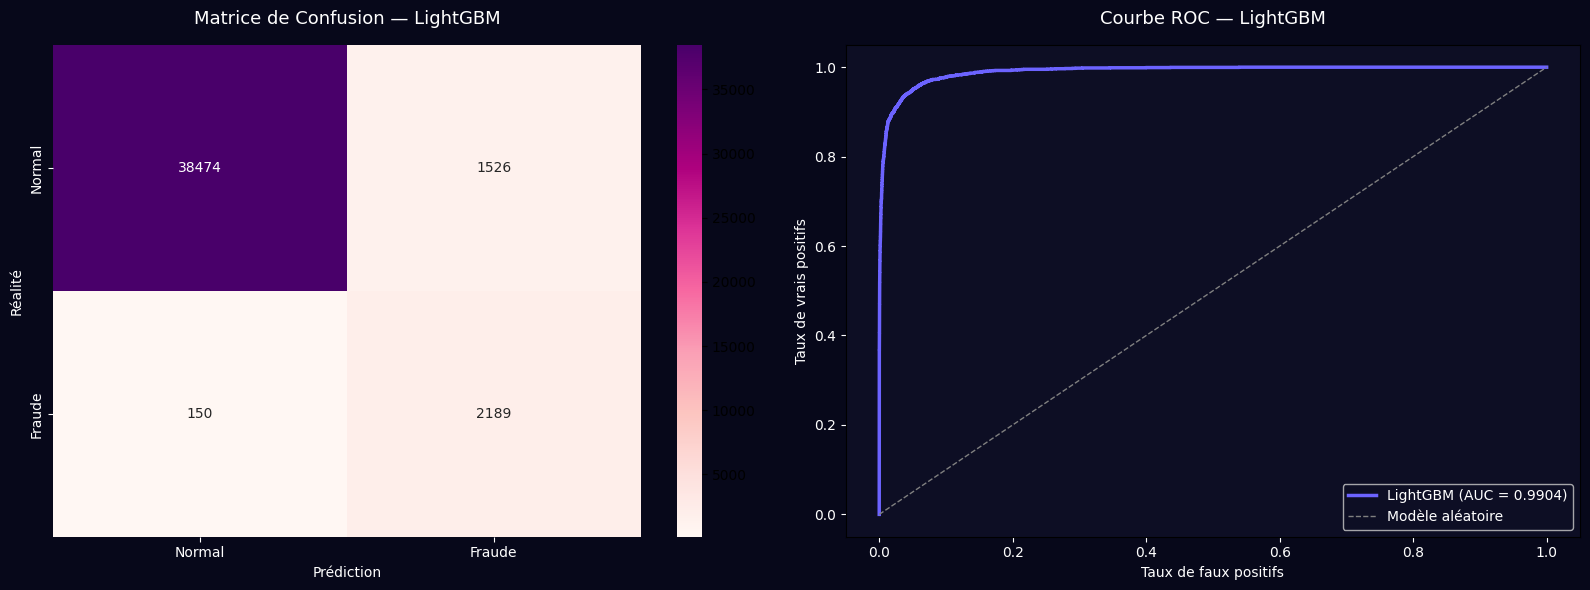

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#07081a')

# ── MATRICE DE CONFUSION ──
cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=axes[0],
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
axes[0].set_title('Matrice de Confusion — LightGBM', color='white', fontsize=13, pad=15)
axes[0].set_xlabel('Prédiction', color='white')
axes[0].set_ylabel('Réalité', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d0e24')

# ── COURBE ROC ──
fpr, tpr, _ = roc_curve(y_test, y_proba_lgb)
auc_score = roc_auc_score(y_test, y_proba_lgb)
axes[1].plot(fpr, tpr, color='#6C63FF', linewidth=2.5, label=f'LightGBM (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Modèle aléatoire')
axes[1].set_title('Courbe ROC — LightGBM', color='white', fontsize=13, pad=15)
axes[1].set_xlabel('Taux de faux positifs', color='white')
axes[1].set_ylabel('Taux de vrais positifs', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d0e24')
axes[1].legend(facecolor='#0d0e24', labelcolor='white')

plt.tight_layout()
plt.savefig('lgbm_results.png', dpi=150, bbox_inches='tight', facecolor='#07081a')
plt.show()

## Résultats LightGBM — Matrice de confusion & Courbe ROC

**Matrice de confusion** :
- **38 474 vrais négatifs** : transactions normales correctement identifiées
- **2 189 vrais positifs** : fraudes correctement détectées
- **150 faux négatifs** : fraudes manquées — le cas le plus coûteux en banque
- **1 526 faux positifs** : transactions légitimes bloquées à tort

Le Recall fraude est de **0,94** — sur 2 339 fraudes dans le jeu de test, 2 189 sont détectées. Les 150 fraudes manquées représentent 6% du total, un niveau acceptable pour un premier modèle en production.

Les 1 526 faux positifs sont le prix à payer pour ce niveau de Recall. En pratique, ces transactions déclenchent une vérification humaine plutôt qu'un blocage définitif — c'est le fonctionnement standard dans les équipes risque.

**Courbe ROC** :
L'AUC de **0,9904** place le modèle très loin du hasard (diagonale pointillée = AUC 0,5). La courbe monte quasi-verticalement dès les premiers seuils, ce qui signifie que le modèle sépare très bien les deux classes avant même d'avoir à accepter beaucoup de faux positifs.

Sur données réelles en production, un AUC entre 0,85 et 0,92 est considéré comme excellent — les 0,99 obtenus ici reflètent la nature synthétique du dataset.

In [53]:
# Vérification overfitting — si le score train est bien supérieur au score test c'est suspect
y_pred_train = model_lgb.predict(X_train)
y_proba_train = model_lgb.predict_proba(X_train)[:, 1]

print("AUC-ROC TRAIN :", round(roc_auc_score(y_train, y_proba_train), 4))
print("AUC-ROC TEST  :", round(roc_auc_score(y_test, y_proba_lgb), 4))
print()
print("Différence :", round(roc_auc_score(y_train, y_proba_train) - roc_auc_score(y_test, y_proba_lgb), 4))

AUC-ROC TRAIN : 0.9946
AUC-ROC TEST  : 0.9904

Différence : 0.0043


In [33]:
from sklearn.model_selection import cross_val_score

# Validation croisée 5 folds — on vérifie la stabilité du modèle
scores = cross_val_score(model_lgb, X_train, y_train, cv=5, scoring='roc_auc', verbose=0)

print("AUC par fold :", scores.round(4))
print("Moyenne      :", round(scores.mean(), 4))
print("Ecart-type   :", round(scores.std(), 4))

AUC par fold : [0.9904 0.9905 0.9892 0.9886 0.9898]
Moyenne      : 0.9897
Ecart-type   : 0.0007


In [54]:
from xgboost import XGBClassifier

# Entraînement XGBoost
# scale_pos_weight gère le déséquilibre : ratio normal/fraude
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

model_xgb = XGBClassifier(n_estimators=300, learning_rate=0.05,
                           scale_pos_weight=scale, random_state=42,
                           eval_metric='auc', verbosity=0)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("AUC-ROC XGBoost :", round(roc_auc_score(y_test, y_proba_xgb), 4))
print("\n", classification_report(y_test, y_pred_xgb))

AUC-ROC XGBoost : 0.9885

               precision    recall  f1-score   support

           0       1.00      0.96      0.98     40000
           1       0.57      0.92      0.71      2339

    accuracy                           0.96     42339
   macro avg       0.78      0.94      0.84     42339
weighted avg       0.97      0.96      0.96     42339



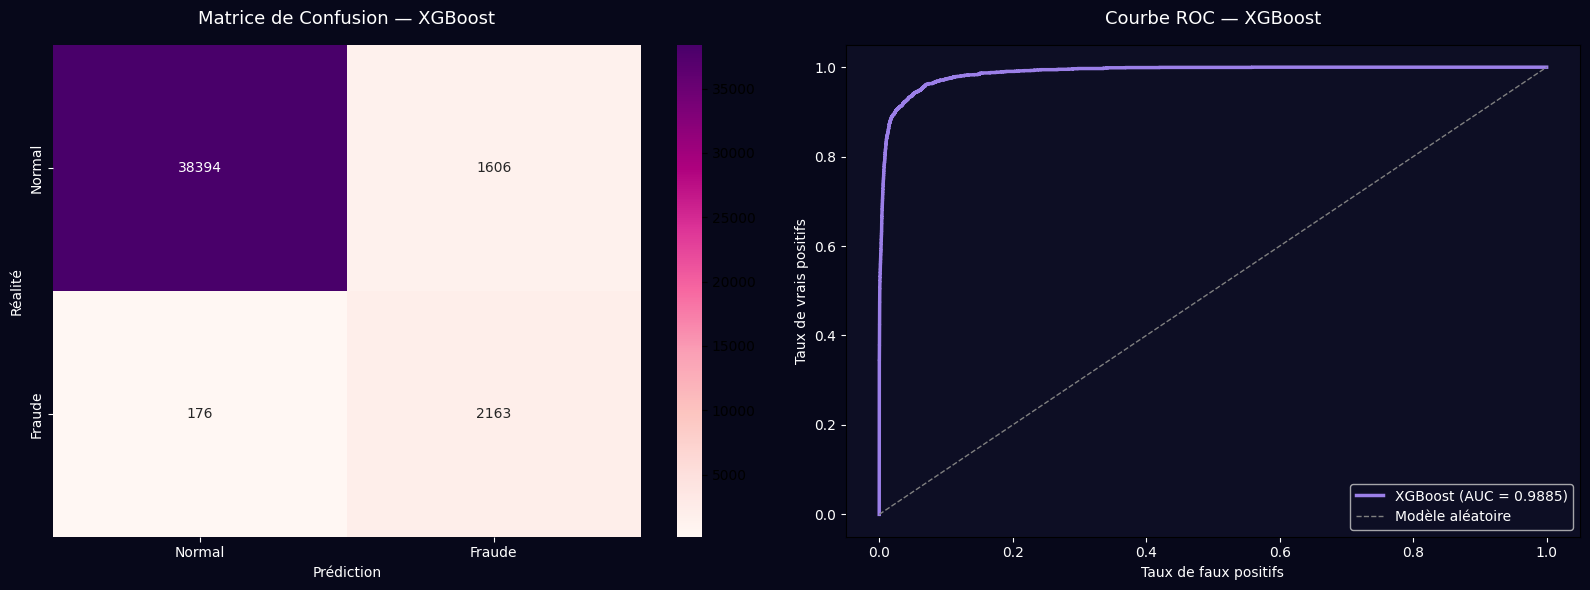

In [55]:
# Visualisation des résultats XGBoost : matrice de confusion + courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#07081a')

# ── Matrice de confusion XGBoost ──
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='RdPu', ax=axes[0],
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
axes[0].set_title('Matrice de Confusion — XGBoost', color='white', fontsize=13, pad=15)
axes[0].set_xlabel('Prédiction', color='white')
axes[0].set_ylabel('Réalité', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0d0e24')

# ── Courbe ROC XGBoost ──
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='#9B7FE8', linewidth=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Modèle aléatoire')
axes[1].set_title('Courbe ROC — XGBoost', color='white', fontsize=13, pad=15)
axes[1].set_xlabel('Taux de faux positifs', color='white')
axes[1].set_ylabel('Taux de vrais positifs', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0d0e24')
axes[1].legend(facecolor='#0d0e24', labelcolor='white')

plt.tight_layout()
plt.savefig('xgb_results.png', dpi=150, bbox_inches='tight', facecolor='#07081a')
plt.show()

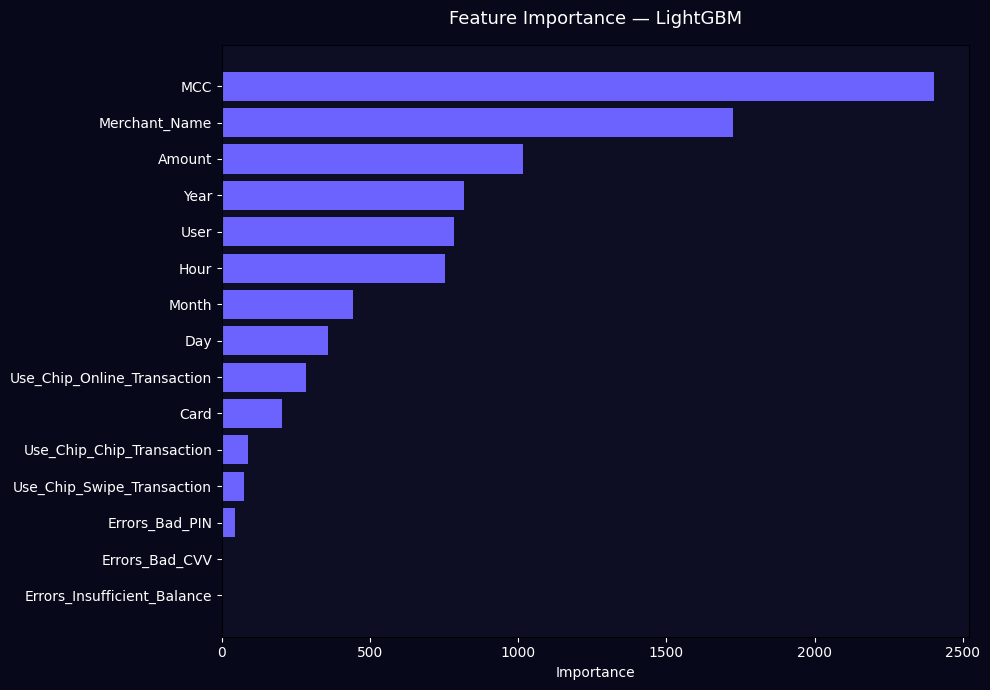

In [56]:
import pandas as pd

# Feature importance — top 15 variables les plus influentes selon LightGBM
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

# Visualisation
plt.figure(figsize=(10, 7))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='#6C63FF')
plt.title('Feature Importance — LightGBM', color='white', fontsize=13, pad=15)
plt.xlabel('Importance', color='white')
plt.tick_params(colors='white')
plt.gca().set_facecolor('#0d0e24')
plt.gcf().set_facecolor('#07081a')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#07081a')
plt.show()

## Feature Importance — LightGBM

Le graphique révèle ce que le modèle a réellement appris à utiliser pour détecter les fraudes.

**MCC (Merchant Category Code)** arrive largement en tête — le type de commerce est le signal le plus prédictif. Certaines catégories (stations service, e-commerce générique, bijouteries...) concentrent structurellement plus de fraude que d'autres. C'est un insight métier fort : le **où** de la transaction prime sur le **comment**.

**Merchant_Name** en deuxième position confirme cette logique — certains marchands précis sont des cibles récurrentes, probablement parce qu'ils ont des systèmes de vérification plus faibles.

**Amount, Year, User, Hour** forment un deuxième groupe homogène — des variables contextuelles qui affinent le scoring mais ne suffisent pas seules.

**Les variables construites** (Use_Chip_Online_Transaction, Errors_Bad_PIN, Errors_Bad_CVV) apparaissent en bas du classement. Cela ne signifie pas qu'elles sont inutiles — elles jouent un rôle sur les cas limites — mais le modèle s'appuie principalement sur le profil du marchand.

L'insight principal : une équipe risque bancaire devrait surveiller en priorité les **catégories et marchands à risque**, avant même de regarder le comportement individuel du client.